Returns loaded: (10330, 117)
Date range    : 1989-07-31 -> 2026-03-13

Assets in correlation universe: 55
Dates with ≥30 assets : 10,284
Full period               : 1990-01-03 -> 2026-03-13

Correlation matrix: (55, 55)
NaN cells         : 0

Correlation distribution (1485 pairs):
  Mean   : +0.052
  Median : +0.044
  Std    : 0.255
  Min    : -0.863
  Max    : +0.974
  >0.7   : 34 pairs (strongly positive)
  <-0.5  : 22 pairs (strongly negative)

Top 10 strongest POSITIVE correlations:
  NASDAQ               ↔  NASDAQ 100            +0.974
  NASDAQ               ↔  XLK Tech              +0.956
  Nikkei               ↔  TOPIX                 +0.956
  NASDAQ 100           ↔  XLK Tech              +0.956
  CAC 40               ↔  EuroStoxx 50          +0.946
  US 10Y               ↔  US 30Y                +0.938
  VSTOXX               ↔  VDAX                  +0.933
  DAX                  ↔  EuroStoxx 50          +0.919
  S&P 500              ↔  NASDAQ                +0.892
  S&P 500    

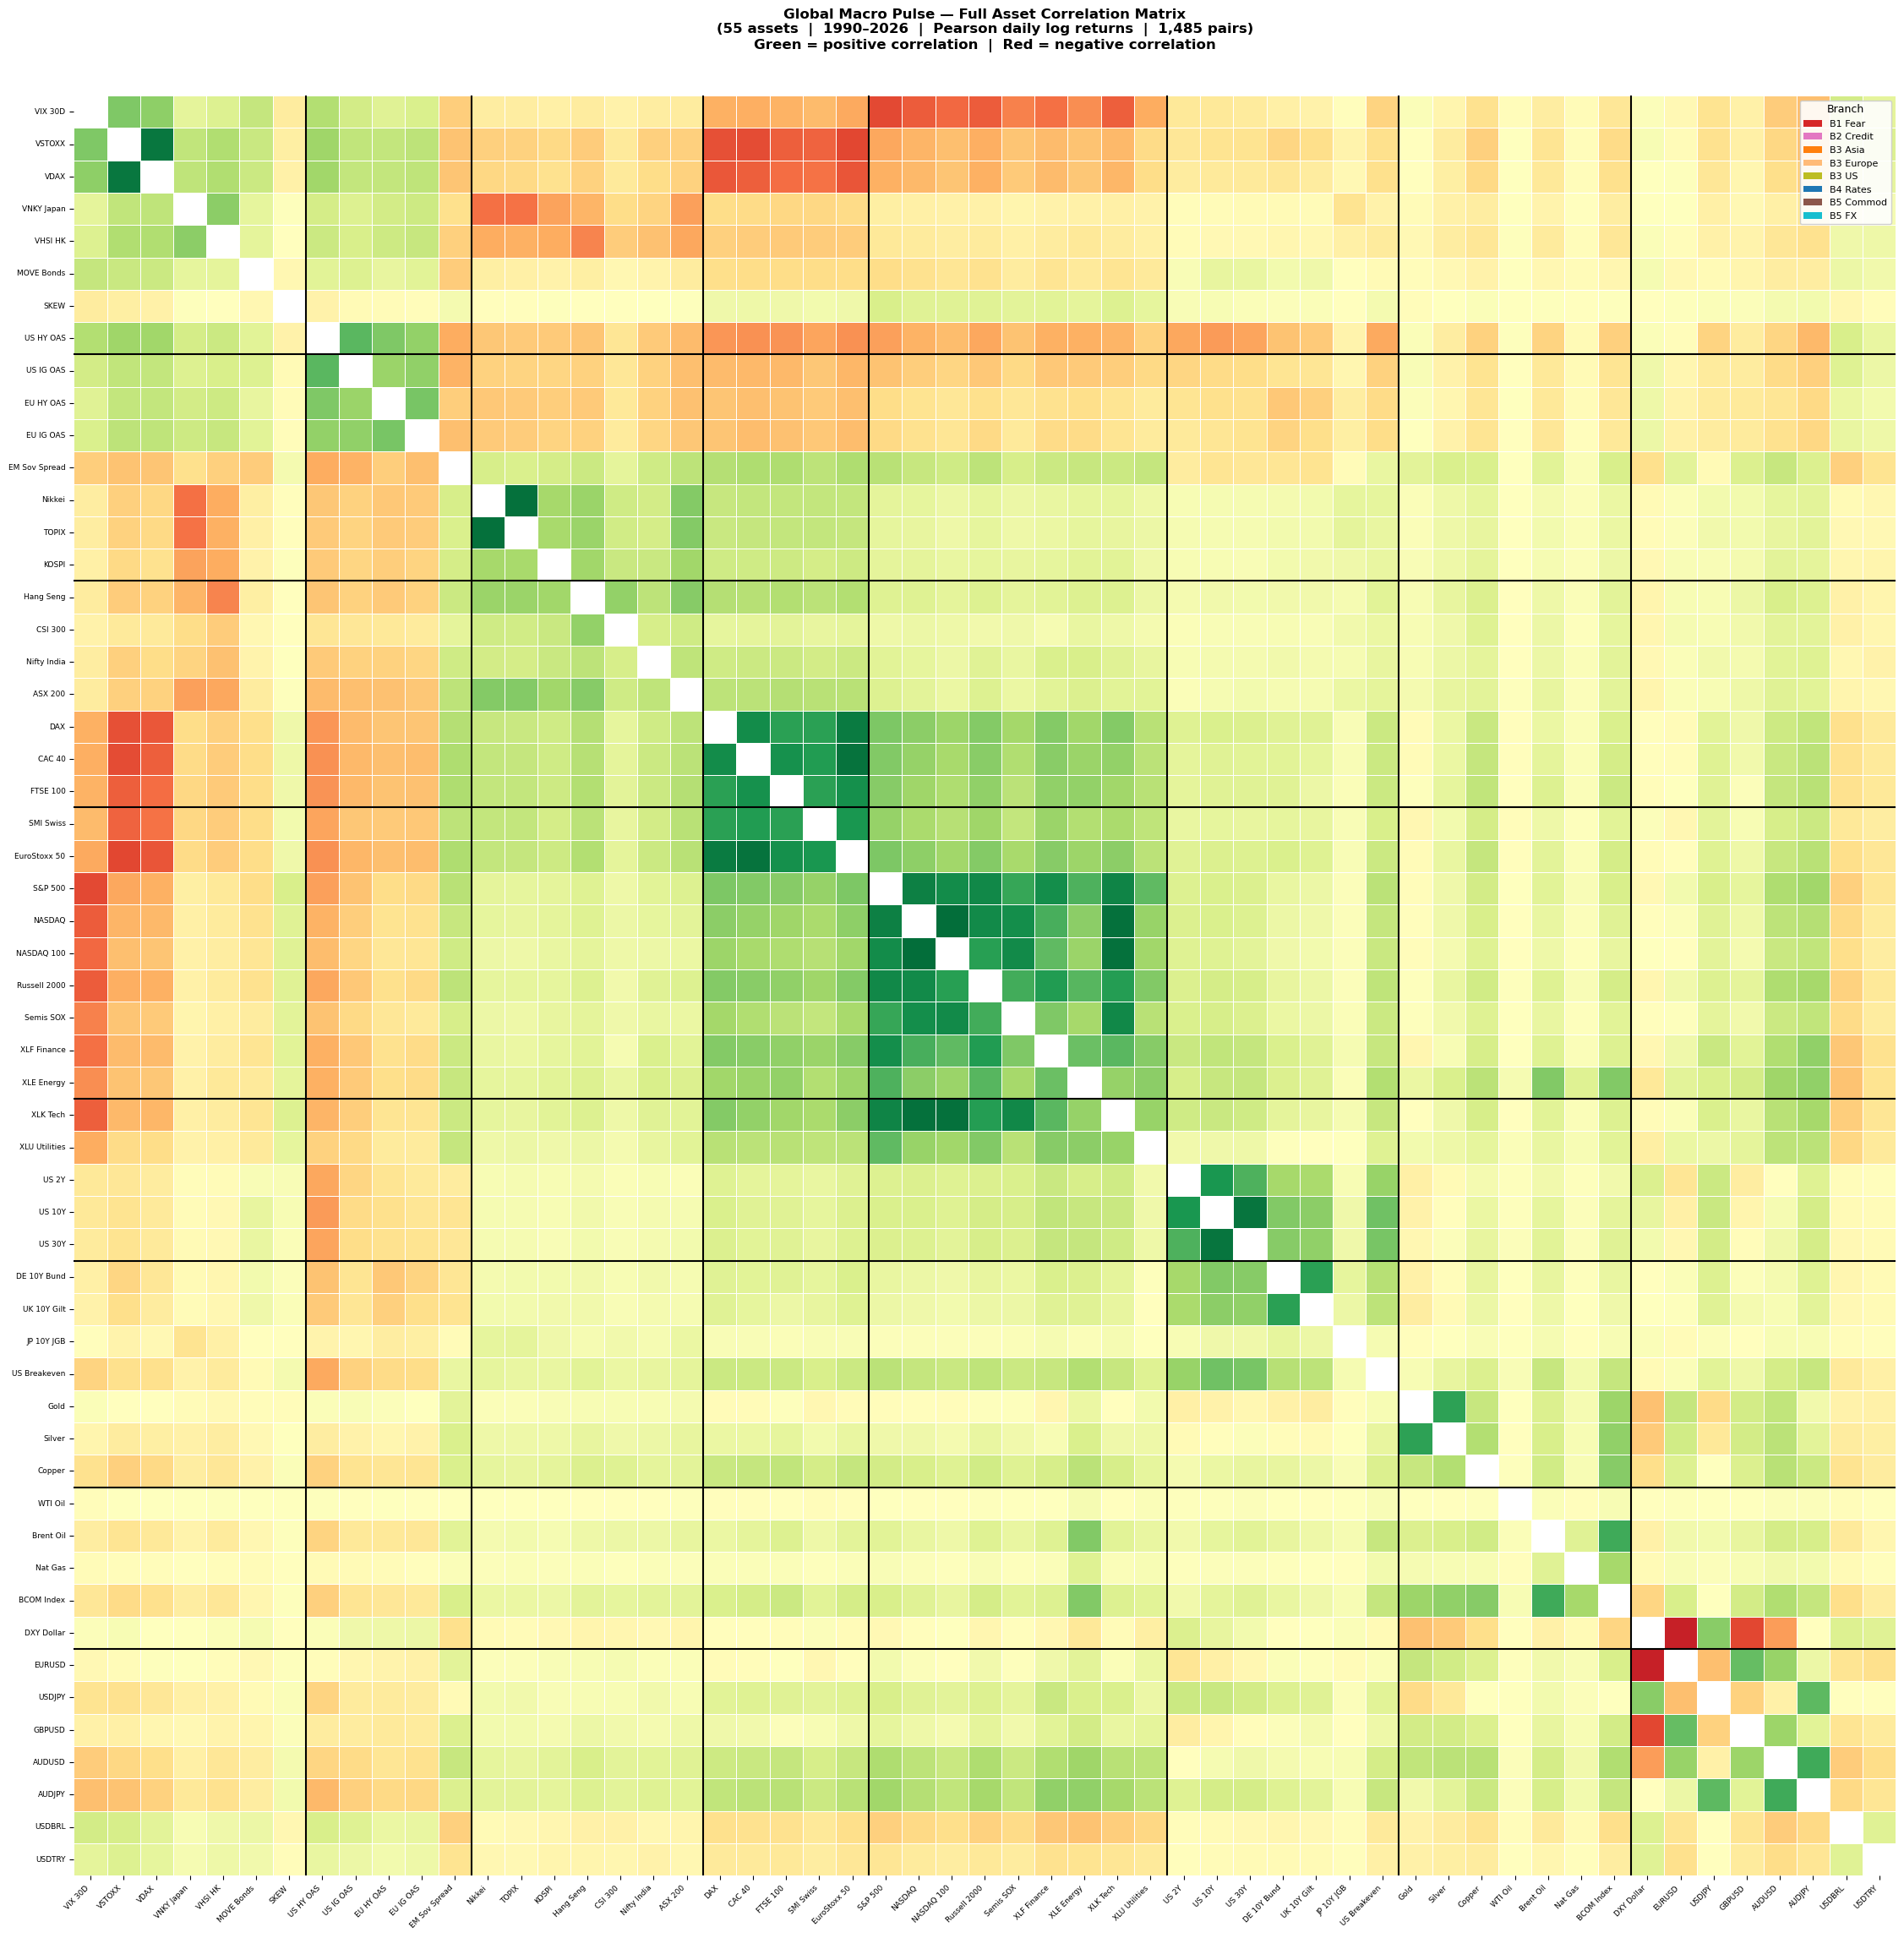


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\09_correlation_full.png
Correlation matrix saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\correlation_matrices\full_period_correlation.csv


In [6]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load master returns ───────────────────────────────────────────────────────
returns = pd.read_csv(cfg.MASTER_RETURNS_FILE, index_col="date", parse_dates=True)

print(f"Returns loaded: {returns.shape}")
print(f"Date range    : {returns.index.min().date()} -> {returns.index.max().date()}")

# ── Define asset universe with labels and branch grouping ─────────────────────
# Order matters — we group by branch so the heatmap is structured

ASSET_MAP = {
    # Branch 1 — Fear & Volatility
    "VIX Index":       ("VIX 30D",        "B1 Fear"),
    "V2X Index":       ("VSTOXX",         "B1 Fear"),
    "V1X Index":       ("VDAX",           "B1 Fear"),
    "VNKY Index":      ("VNKY Japan",     "B1 Fear"),
    "VHSI Index":      ("VHSI HK",        "B1 Fear"),
    "MOVE Index":      ("MOVE Bonds",     "B1 Fear"),
    "SKEW Index":      ("SKEW",           "B1 Fear"),

    # Branch 2 — Credit
    "LF98OAS Index":   ("US HY OAS",      "B2 Credit"),
    "LUACOAS Index":   ("US IG OAS",      "B2 Credit"),
    "LP01OAS Index":   ("EU HY OAS",      "B2 Credit"),
    "LECPOAS Index":   ("EU IG OAS",      "B2 Credit"),
    "JPEIGLBL Index":  ("EM Sov Spread",  "B2 Credit"),

    # Branch 3 — Equities Asia
    "NKY Index":       ("Nikkei",         "B3 Asia"),
    "TPX Index":       ("TOPIX",          "B3 Asia"),
    "KOSPI Index":     ("KOSPI",          "B3 Asia"),
    "HSI Index":       ("Hang Seng",      "B3 Asia"),
    "SHSZ300 Index":   ("CSI 300",        "B3 Asia"),
    "NIFTY Index":     ("Nifty India",    "B3 Asia"),
    "AS51 Index":      ("ASX 200",        "B3 Asia"),

    # Branch 3 — Equities Europe
    "DAX Index":       ("DAX",            "B3 Europe"),
    "CAC Index":       ("CAC 40",         "B3 Europe"),
    "UKX Index":       ("FTSE 100",       "B3 Europe"),
    "SMI Index":       ("SMI Swiss",      "B3 Europe"),
    "SX5E Index":      ("EuroStoxx 50",   "B3 Europe"),

    # Branch 3 — Equities US
    "SPX Index":       ("S&P 500",        "B3 US"),
    "CCMP Index":      ("NASDAQ",         "B3 US"),
    "NDX Index":       ("NASDAQ 100",     "B3 US"),
    "RTY Index":       ("Russell 2000",   "B3 US"),
    "SOX Index":       ("Semis SOX",      "B3 US"),
    "XLF US Equity":   ("XLF Finance",    "B3 US"),
    "XLE US Equity":   ("XLE Energy",     "B3 US"),
    "XLK US Equity":   ("XLK Tech",       "B3 US"),
    "XLU US Equity":   ("XLU Utilities",  "B3 US"),

    # Branch 4 — Rates
    "USGG2YR Index":   ("US 2Y",          "B4 Rates"),
    "USGG10YR Index":  ("US 10Y",         "B4 Rates"),
    "USGG30YR Index":  ("US 30Y",         "B4 Rates"),
    "GDBR10 Index":    ("DE 10Y Bund",    "B4 Rates"),
    "GUKG10 Index":    ("UK 10Y Gilt",    "B4 Rates"),
    "GJGB10 Index":    ("JP 10Y JGB",     "B4 Rates"),
    "USGGBE10 Index":  ("US Breakeven",   "B4 Rates"),

    # Branch 5 — Commodities
    "GC1 Comdty":      ("Gold",           "B5 Commod"),
    "SI1 Comdty":      ("Silver",         "B5 Commod"),
    "HG1 Comdty":      ("Copper",         "B5 Commod"),
    "CL1 Comdty":      ("WTI Oil",        "B5 Commod"),
    "CO1 Comdty":      ("Brent Oil",      "B5 Commod"),
    "NG1 Comdty":      ("Nat Gas",        "B5 Commod"),
    "BCOM Index":      ("BCOM Index",     "B5 Commod"),

    # Branch 5 — FX
    "DXY Curncy":      ("DXY Dollar",     "B5 FX"),
    "EURUSD Curncy":   ("EURUSD",         "B5 FX"),
    "USDJPY Curncy":   ("USDJPY",         "B5 FX"),
    "GBPUSD Curncy":   ("GBPUSD",         "B5 FX"),
    "AUDUSD Curncy":   ("AUDUSD",         "B5 FX"),
    "AUDJPY Curncy":   ("AUDJPY",         "B5 FX"),
    "USDBRL Curncy":   ("USDBRL",         "B5 FX"),
    "USDTRY Curncy":   ("USDTRY",         "B5 FX"),
}

# ── Filter to available tickers ───────────────────────────────────────────────
available = {k: v for k, v in ASSET_MAP.items() if k in returns.columns}
print(f"\nAssets in correlation universe: {len(available)}")

tickers    = list(available.keys())
labels     = [available[t][0] for t in tickers]
branches   = [available[t][1] for t in tickers]

# ── Extract returns for this universe ─────────────────────────────────────────
ret_universe = returns[tickers].copy()

# Use dates where we have at least 30 assets with data
min_assets   = 30
ret_filtered = ret_universe[ret_universe.notna().sum(axis=1) >= min_assets]

print(f"Dates with ≥{min_assets} assets : {len(ret_filtered):,}")
print(f"Full period               : {ret_filtered.index.min().date()} -> "
      f"{ret_filtered.index.max().date()}")


# ── Compute full-period correlation matrix ────────────────────────────────────
# Use pairwise complete observations (each pair uses all dates where both exist)
corr_matrix = ret_filtered.corr(method="pearson", min_periods=252)

# Rename columns and index to short labels
corr_matrix.index   = labels
corr_matrix.columns = labels

print(f"\nCorrelation matrix: {corr_matrix.shape}")
print(f"NaN cells         : {corr_matrix.isna().sum().sum()}")


# ── Basic correlation statistics ──────────────────────────────────────────────
# Get upper triangle (excluding diagonal) for distribution analysis
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
all_corrs = upper_tri.stack().dropna()

print(f"\nCorrelation distribution ({len(all_corrs)} pairs):")
print(f"  Mean   : {all_corrs.mean():>+.3f}")
print(f"  Median : {all_corrs.median():>+.3f}")
print(f"  Std    : {all_corrs.std():>.3f}")
print(f"  Min    : {all_corrs.min():>+.3f}")
print(f"  Max    : {all_corrs.max():>+.3f}")
print(f"  >0.7   : {(all_corrs > 0.7).sum()} pairs (strongly positive)")
print(f"  <-0.5  : {(all_corrs < -0.5).sum()} pairs (strongly negative)")


# ── Find strongest positive and negative correlations ────────────────────────
print(f"\nTop 10 strongest POSITIVE correlations:")
top_pos = all_corrs.sort_values(ascending=False).head(10)
for (a, b), corr in top_pos.items():
    print(f"  {a:<20} ↔  {b:<20}  {corr:>+.3f}")

print(f"\nTop 10 strongest NEGATIVE correlations:")
top_neg = all_corrs.sort_values(ascending=True).head(10)
for (a, b), corr in top_neg.items():
    print(f"  {a:<20} ↔  {b:<20}  {corr:>+.3f}")


branch_colors = {
    "B1 Fear":    "#d62728",
    "B2 Credit":  "#e377c2",
    "B3 Asia":    "#ff7f0e",
    "B3 Europe":  "#ffbb78",
    "B3 US":      "#bcbd22",
    "B4 Rates":   "#1f77b4",
    "B5 Commod":  "#8c564b",
    "B5 FX":      "#17becf",
}

n = len(labels)

fig, ax_main = plt.subplots(figsize=(28, 26))

# ── Heatmap ───────────────────────────────────────────────────────────────────
mask = np.eye(n, dtype=bool)
sns.heatmap(
    corr_matrix,
    ax         = ax_main,
    cmap       = "RdYlGn",
    center     = 0,
    vmin       = -1, vmax = 1,
    mask       = mask,
    linewidths = 0.4,
    linecolor  = "white",
    annot      = False,
    cbar       = False
)

# ── Tick labels ───────────────────────────────────────────────────────────────
ax_main.set_xticklabels(
    ax_main.get_xticklabels(),
    rotation=45, ha="right", fontsize=6.5
)
ax_main.set_yticklabels(
    ax_main.get_yticklabels(),
    rotation=0, fontsize=6.5
)



# ── Branch group separators ───────────────────────────────────────────────────
prev_branch = branches[0]
for i, branch in enumerate(branches):
    if branch != prev_branch:
        ax_main.axhline(n - i, color="black", lw=1.5, zorder=6)
        ax_main.axvline(i,     color="black", lw=1.5, zorder=6)
        prev_branch = branch



# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=branch)
    for branch, color in branch_colors.items()
]
ax_main.legend(
    handles        = legend_elements,
    fontsize       = 8,
    loc            = "upper right",
    framealpha     = 0.9,
    title          = "Branch",
    title_fontsize = 9
)

# ── Title ─────────────────────────────────────────────────────────────────────
ax_main.set_title(
    f"Global Macro Pulse — Full Asset Correlation Matrix\n"
    f"({len(tickers)} assets  |  "
    f"{ret_filtered.index.min().year}–{ret_filtered.index.max().year}  |  "
    f"Pearson daily log returns  |  1,485 pairs)\n"
    f"Green = positive correlation  |  Red = negative correlation",
    fontsize=12, fontweight="bold", pad=40
)

plt.subplots_adjust(left=0.18, right=0.95, top=0.93, bottom=0.12)
chart_path = os.path.join(cfg.OUT_PATH, "charts", "09_correlation_full.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

corr_out_path = os.path.join(
    cfg.OUT_PATH, "correlation_matrices", "full_period_correlation.csv"
)
corr_matrix.to_csv(corr_out_path)
print(f"Correlation matrix saved: {corr_out_path}")

Rolling correlations computed for pairs:
  Asia → Europe           1M=+0.254  3M=+0.282  1Y=+0.487
  Europe → US             1M=+0.434  3M=+0.405  1Y=+0.244
  US → Asia               1M=-0.131  3M=+0.066  1Y=-0.018
  VIX vs SPX              1M=-0.888  3M=-0.834  1Y=-0.856
  MOVE vs US 10Y          1M=-0.363  3M=-0.162  1Y=+0.016
  Gold vs SPX             1M=+0.089  3M=+0.154  1Y=+0.045
  Gold vs DXY             1M=-0.528  3M=-0.495  1Y=-0.456
  JPY vs SPX              1M=+0.161  3M=+0.015  1Y=+0.269
  US HY vs SPX            1M=-0.653  3M=-0.720  1Y=-0.763
  Copper vs SPX           1M=+0.531  3M=+0.307  1Y=+0.239
  Oil vs SPX              1M=-0.393  3M=-0.201  1Y=+0.140
  AUDJPY vs SPX           1M=+0.639  3M=+0.498  1Y=+0.665
  US 10Y vs SPX           1M=+0.162  3M=+0.144  1Y=+0.069

Correlation Instability (higher = more unstable = regime changing):
------------------------------------------------------------
  Asia → Europe           instability=0.142  Z=-0.86  ✓ Stable
  Europe → U

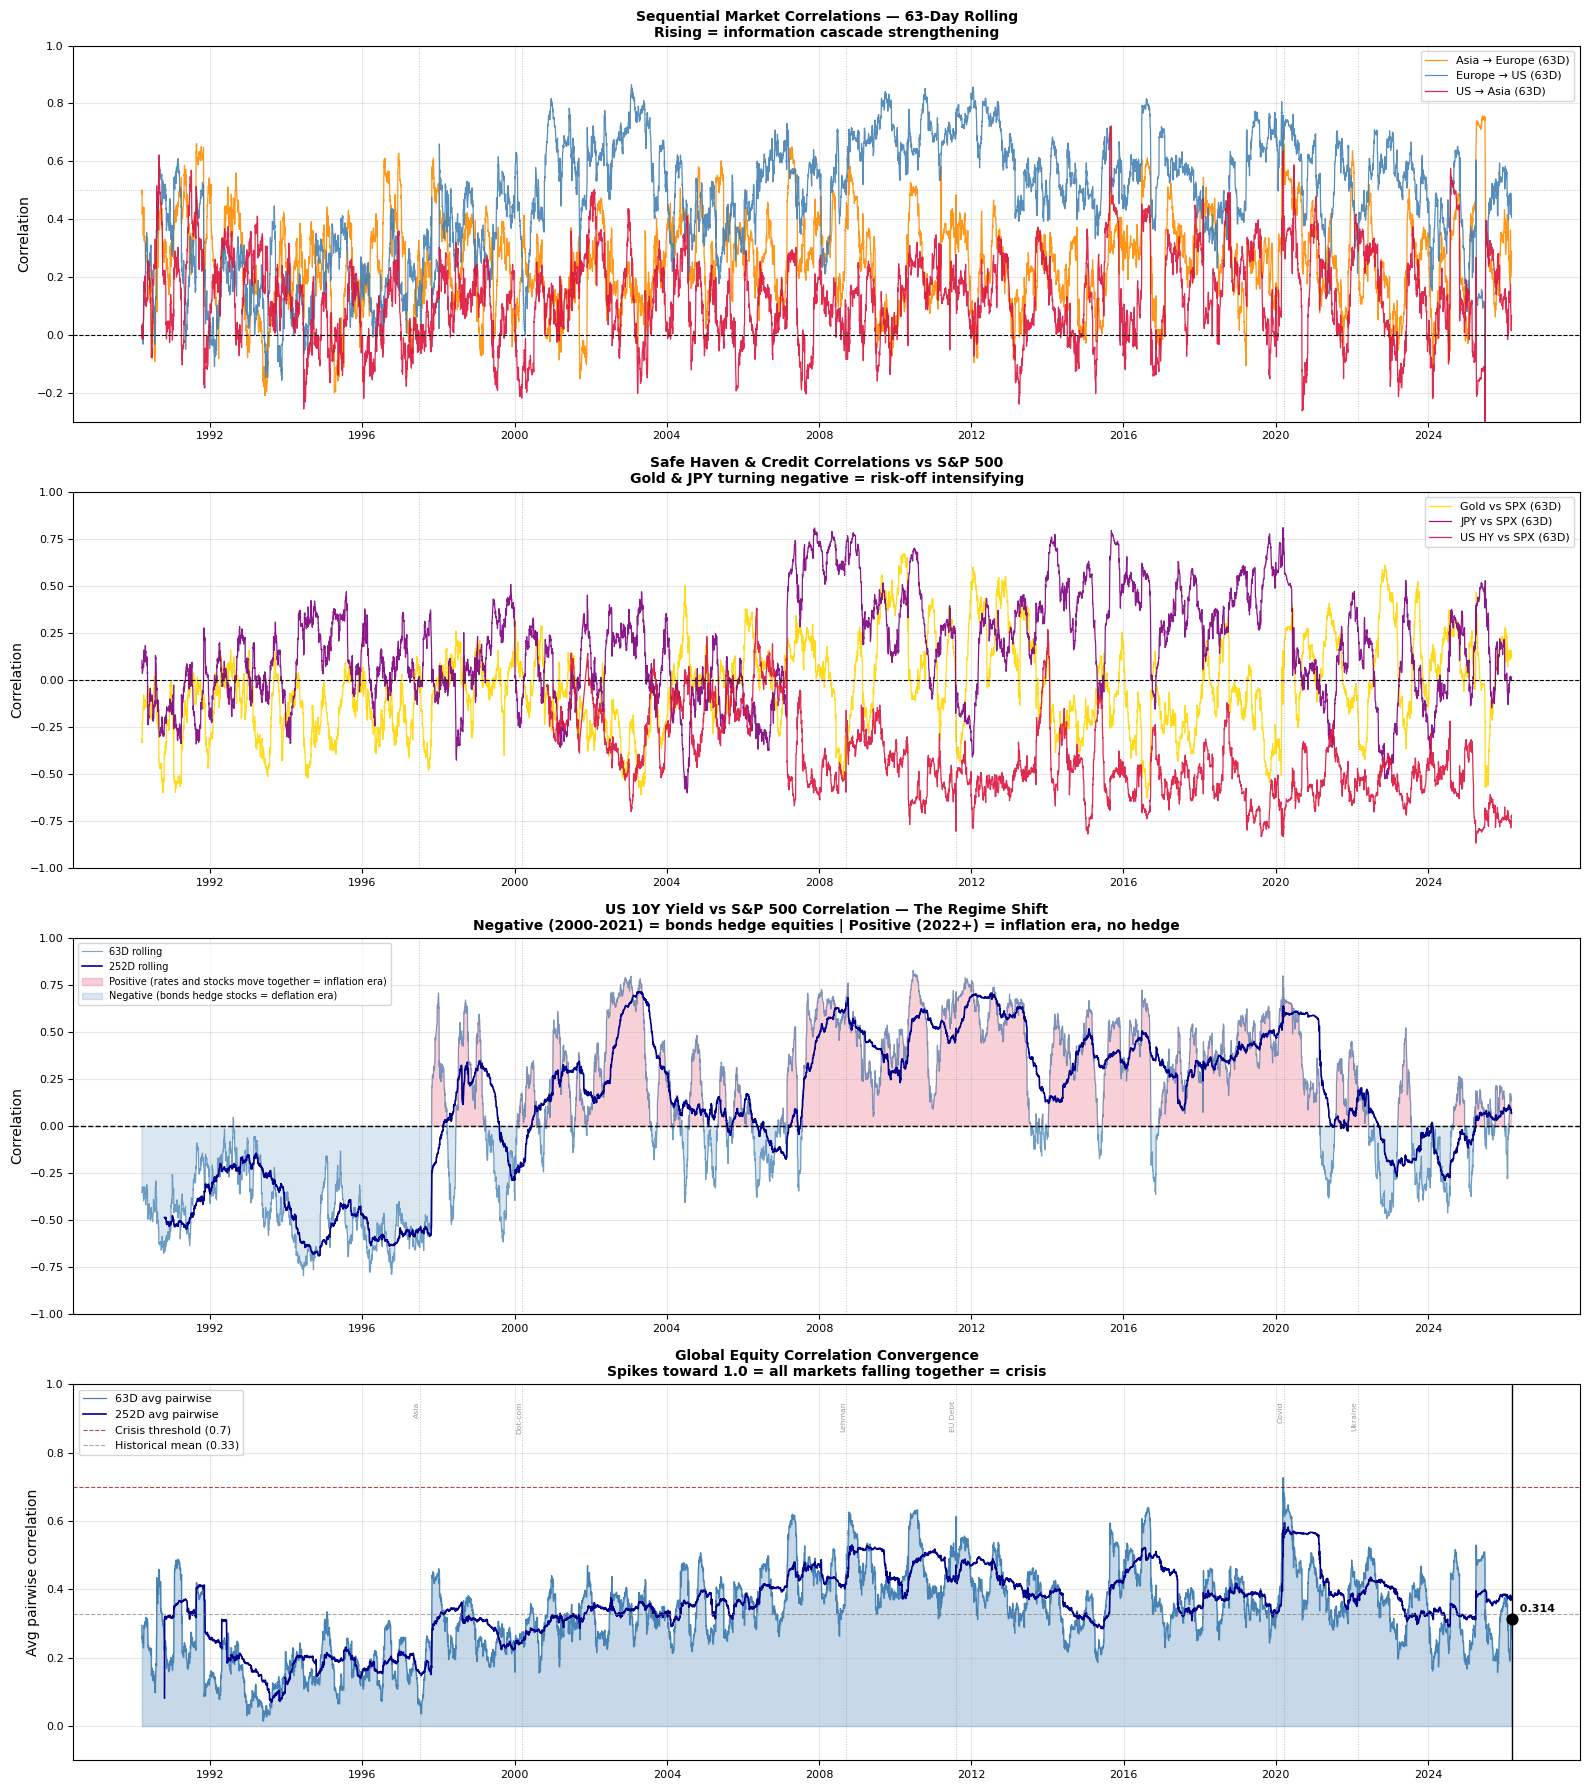


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\09_correlation_rolling.png
Rolling correlations saved.


In [8]:
# ── Cell 2: Rolling Correlation Engine ───────────────────────────────────────
# 
# Static correlations tell you the average relationship.
# Rolling correlations tell you how that relationship CHANGES over time.
# The changes are where the edge lives.
import matplotlib.dates as mdates
# ── 2A: Define the most important asset pairs to track ────────────────────────
PAIRS = {
    # Equity cross-regional (sequential signal pairs)
    "Asia → Europe":      ("NKY Index",      "DAX Index"),
    "Europe → US":        ("DAX Index",       "SPX Index"),
    "US → Asia":          ("SPX Index",       "NKY Index"),

    # Fear vs equity (risk-off signal)
    "VIX vs SPX":         ("VIX Index",       "SPX Index"),
    "MOVE vs US 10Y":     ("MOVE Index",      "USGG10YR Index"),

    # Safe haven relationships
    "Gold vs SPX":        ("GC1 Comdty",      "SPX Index"),
    "Gold vs DXY":        ("GC1 Comdty",      "DXY Curncy"),
    "JPY vs SPX":         ("USDJPY Curncy",   "SPX Index"),

    # Credit vs equity (early warning)
    "US HY vs SPX":       ("LF98OAS Index",   "SPX Index"),

    # Commodity vs equity (growth signal)
    "Copper vs SPX":      ("HG1 Comdty",      "SPX Index"),
    "Oil vs SPX":         ("CL1 Comdty",      "SPX Index"),

    # Cross-asset carry
    "AUDJPY vs SPX":      ("AUDJPY Curncy",   "SPX Index"),

    # Rates vs equity (the regime-dependent relationship)
    "US 10Y vs SPX":      ("USGG10YR Index",  "SPX Index"),
}

# ── 2B: Compute rolling correlations for all pairs ────────────────────────────
WINDOWS = [21, 63, 252]   # 1M, 3M, 1Y

rolling_corrs = {}

for pair_name, (t1, t2) in PAIRS.items():
    if t1 not in returns.columns or t2 not in returns.columns:
        print(f"Skipping {pair_name} — ticker not found")
        continue

    s1 = returns[t1].dropna()
    s2 = returns[t2].dropna()

    rolling_corrs[pair_name] = {}
    for window in WINDOWS:
        rolling_corrs[pair_name][window] = s1.rolling(window).corr(s2)

print("Rolling correlations computed for pairs:")
for pair_name in rolling_corrs:
    cur_21  = rolling_corrs[pair_name][21].dropna().iloc[-1]
    cur_63  = rolling_corrs[pair_name][63].dropna().iloc[-1]
    cur_252 = rolling_corrs[pair_name][252].dropna().iloc[-1]
    print(f"  {pair_name:<22}  1M={cur_21:>+.3f}  3M={cur_63:>+.3f}  1Y={cur_252:>+.3f}")


# ── 2C: Correlation instability index ────────────────────────────────────────
# How much is the correlation CHANGING?
# High instability = regime change happening
# Measure: rolling std of the 21-day rolling correlation over past 63 days

print(f"\nCorrelation Instability (higher = more unstable = regime changing):")
print("-"*60)

instability = {}
for pair_name in rolling_corrs:
    roll_21 = rolling_corrs[pair_name][21].dropna()
    # Instability = rolling std of the 21-day correlation
    inst = roll_21.rolling(63).std()
    instability[pair_name] = inst
    cur_inst  = inst.dropna().iloc[-1]
    hist_mean = inst.dropna().mean()
    z_inst    = (cur_inst - hist_mean) / inst.dropna().std()
    flag      = "⚠ UNSTABLE" if z_inst > 1.5 else "✓ Stable"
    print(f"  {pair_name:<22}  instability={cur_inst:.3f}  "
          f"Z={z_inst:>+.2f}  {flag}")


# ── 2D: Crisis correlation convergence analysis ───────────────────────────────
# During crises, ALL correlations converge toward 1 or -1
# Measure: average absolute correlation across all equity pairs

equity_tickers_roll = [
    "SPX Index", "DAX Index", "NKY Index", "HSI Index",
    "KOSPI Index", "CAC Index", "UKX Index", "NIFTY Index", "AS51 Index"
]
equity_tickers_roll = [t for t in equity_tickers_roll if t in returns.columns]

# Rolling average pairwise correlation among equities
def rolling_avg_corr(df, window=63):
    """Compute rolling average pairwise correlation across all columns."""
    result = pd.Series(index=df.index, dtype=float)
    cols   = df.columns.tolist()
    pairs_list = [(c1, c2) for i, c1 in enumerate(cols)
                  for c2 in cols[i+1:]]

    pair_corrs = []
    for c1, c2 in pairs_list:
        pair_corrs.append(df[c1].rolling(window).corr(df[c2]))

    avg = pd.concat(pair_corrs, axis=1).mean(axis=1)
    return avg

eq_ret = returns[equity_tickers_roll].copy()
avg_eq_corr_63  = rolling_avg_corr(eq_ret, window=63)
avg_eq_corr_252 = rolling_avg_corr(eq_ret, window=252)

cur_avg_corr = avg_eq_corr_63.dropna().iloc[-1]
hist_avg     = avg_eq_corr_63.dropna().mean()
z_corr       = (cur_avg_corr - hist_avg) / avg_eq_corr_63.dropna().std()

print(f"\nGlobal Equity Correlation Convergence:")
print(f"  Current 63D avg pairwise corr : {cur_avg_corr:.3f}")
print(f"  Historical mean               : {hist_avg:.3f}")
print(f"  Z-score                       : {z_corr:>+.2f}")
regime_corr = ("CRISIS — all markets moving together"
               if cur_avg_corr > 0.7 else
               "ELEVATED — markets more correlated than usual"
               if cur_avg_corr > 0.5 else
               "NORMAL" if cur_avg_corr > 0.3 else
               "DECOUPLED — regional factors dominating")
print(f"  Regime                        : {regime_corr}")


# ── 2E: Plots ─────────────────────────────────────────────────────────────────
CRISES = [
    ("1997-07-02","Asia"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2011-08-05","EU Debt"),
    ("2020-03-16","Covid"),("2022-02-24","Ukraine"),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 18))

# ── Panel 1: Sequential market correlations ───────────────────────────────────
ax1 = axes[0]
seq_pairs = ["Asia → Europe", "Europe → US", "US → Asia"]
seq_colors = ["darkorange", "steelblue", "crimson"]
for pair, color in zip(seq_pairs, seq_colors):
    if pair in rolling_corrs:
        s = rolling_corrs[pair][63].dropna()
        ax1.plot(s.index, s.values, lw=0.9, color=color,
                 alpha=0.9, label=f"{pair} (63D)")
ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.axhline(0.5, color="grey", lw=0.6, ls=":", alpha=0.6)
for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax1.set_title("Sequential Market Correlations — 63-Day Rolling\n"
              "Rising = information cascade strengthening",
              fontsize=10, fontweight="bold")
ax1.set_ylabel("Correlation")
ax1.legend(fontsize=8)
ax1.set_ylim(-0.3, 1.0)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# ── Panel 2: Safe haven correlations ─────────────────────────────────────────
ax2 = axes[1]
safe_pairs  = ["Gold vs SPX", "JPY vs SPX", "US HY vs SPX"]
safe_colors = ["gold", "purple", "crimson"]
for pair, color in zip(safe_pairs, safe_colors):
    if pair in rolling_corrs:
        s = rolling_corrs[pair][63].dropna()
        ax2.plot(s.index, s.values, lw=0.9, color=color,
                 alpha=0.9, label=f"{pair} (63D)")
ax2.axhline(0, color="black", lw=0.8, ls="--")
for crisis_date, label in CRISES:
    ax2.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax2.set_title("Safe Haven & Credit Correlations vs S&P 500\n"
              "Gold & JPY turning negative = risk-off intensifying",
              fontsize=10, fontweight="bold")
ax2.set_ylabel("Correlation")
ax2.legend(fontsize=8)
ax2.set_ylim(-1.0, 1.0)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# ── Panel 3: US 10Y vs SPX — the regime-dependent relationship ───────────────
ax3 = axes[2]
if "US 10Y vs SPX" in rolling_corrs:
    s63  = rolling_corrs["US 10Y vs SPX"][63].dropna()
    s252 = rolling_corrs["US 10Y vs SPX"][252].dropna()
    ax3.plot(s63.index,  s63.values,  lw=0.8, color="steelblue",
             alpha=0.7, label="63D rolling")
    ax3.plot(s252.index, s252.values, lw=1.2, color="darkblue",
             label="252D rolling")
    ax3.fill_between(s63.index, s63.values, 0,
                     where=s63.values > 0,
                     alpha=0.2, color="crimson",
                     label="Positive (rates and stocks move together = inflation era)")
    ax3.fill_between(s63.index, s63.values, 0,
                     where=s63.values < 0,
                     alpha=0.2, color="steelblue",
                     label="Negative (bonds hedge stocks = deflation era)")
ax3.axhline(0, color="black", lw=1.0, ls="--")
for crisis_date, label in CRISES:
    ax3.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax3.set_title("US 10Y Yield vs S&P 500 Correlation — The Regime Shift\n"
              "Negative (2000-2021) = bonds hedge equities | "
              "Positive (2022+) = inflation era, no hedge",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Correlation")
ax3.legend(fontsize=7)
ax3.set_ylim(-1.0, 1.0)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

# ── Panel 4: Global equity correlation convergence ───────────────────────────
ax4 = axes[3]
ax4.fill_between(avg_eq_corr_63.index, avg_eq_corr_63.values,
                 alpha=0.3, color="steelblue")
ax4.plot(avg_eq_corr_63.index,  avg_eq_corr_63.values,
         lw=0.9, color="steelblue", label="63D avg pairwise")
ax4.plot(avg_eq_corr_252.index, avg_eq_corr_252.values,
         lw=1.2, color="darkblue",  label="252D avg pairwise")
ax4.axhline(0.7, color="darkred",   lw=0.8, ls="--",
            alpha=0.7, label="Crisis threshold (0.7)")
ax4.axhline(hist_avg, color="grey", lw=0.8, ls="--",
            alpha=0.7, label=f"Historical mean ({hist_avg:.2f})")

# Mark current
ax4.axvline(avg_eq_corr_63.dropna().index[-1], color="black", lw=1.0)
ax4.scatter([avg_eq_corr_63.dropna().index[-1]], [cur_avg_corr],
            s=60, color="black", zorder=5)
ax4.text(avg_eq_corr_63.dropna().index[-1], cur_avg_corr + 0.02,
         f"  {cur_avg_corr:.3f}", fontsize=8, fontweight="bold")

for crisis_date, label in CRISES:
    ax4.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
    ax4.text(pd.Timestamp(crisis_date), 0.95, label,
             fontsize=5.5, rotation=90, va="top", ha="right",
             color="grey", alpha=0.8)

ax4.set_title("Global Equity Correlation Convergence\n"
              "Spikes toward 1.0 = all markets falling together = crisis",
              fontsize=10, fontweight="bold")
ax4.set_ylabel("Avg pairwise correlation")
ax4.set_ylim(-0.1, 1.0)
ax4.legend(fontsize=8)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax4.tick_params(labelsize=8); ax4.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "09_correlation_rolling.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save rolling correlations ─────────────────────────────────────────────────
roll_out = pd.DataFrame({
    f"{pair}_{w}d": rolling_corrs[pair][w]
    for pair in rolling_corrs
    for w in WINDOWS
})
roll_out["avg_equity_corr_63d"]  = avg_eq_corr_63
roll_out["avg_equity_corr_252d"] = avg_eq_corr_252
roll_out.to_csv(os.path.join(
    cfg.OUT_PATH, "correlation_matrices", "rolling_correlations.csv"
))
print("Rolling correlations saved.")

Macro regime distribution:
macro_regime
TRANSITIONAL    4483
RATE CYCLE      2688
RISK-ON         1526
CRISIS           852
RISK-OFF         611

Conditional Correlations by Macro Regime:
  Pair                       ALL   RISK-ON   RISK-OFF    CRISIS   RATE CYCLE
-------------------------------------------------------------------------------------
  Asia → Europe           +0.269    +0.207     +0.333    +0.362       +0.267
  Europe → US             +0.527    +0.542     +0.453    +0.627       +0.519
  US → Asia               +0.133    +0.099     +0.183    +0.170       +0.196
  VIX vs SPX              -0.715    -0.759     -0.812    -0.774       -0.676
  MOVE vs US 10Y          +0.122    +0.264     +0.067    -0.049       +0.115 ← REGIME DEPENDENT
  Gold vs SPX             -0.017    +0.059     -0.006    -0.008       -0.064
  Gold vs DXY             -0.326    -0.410     -0.377    -0.381       -0.265
  JPY vs SPX              +0.198    +0.182     +0.132    +0.427       +0.060
  US HY vs SPX

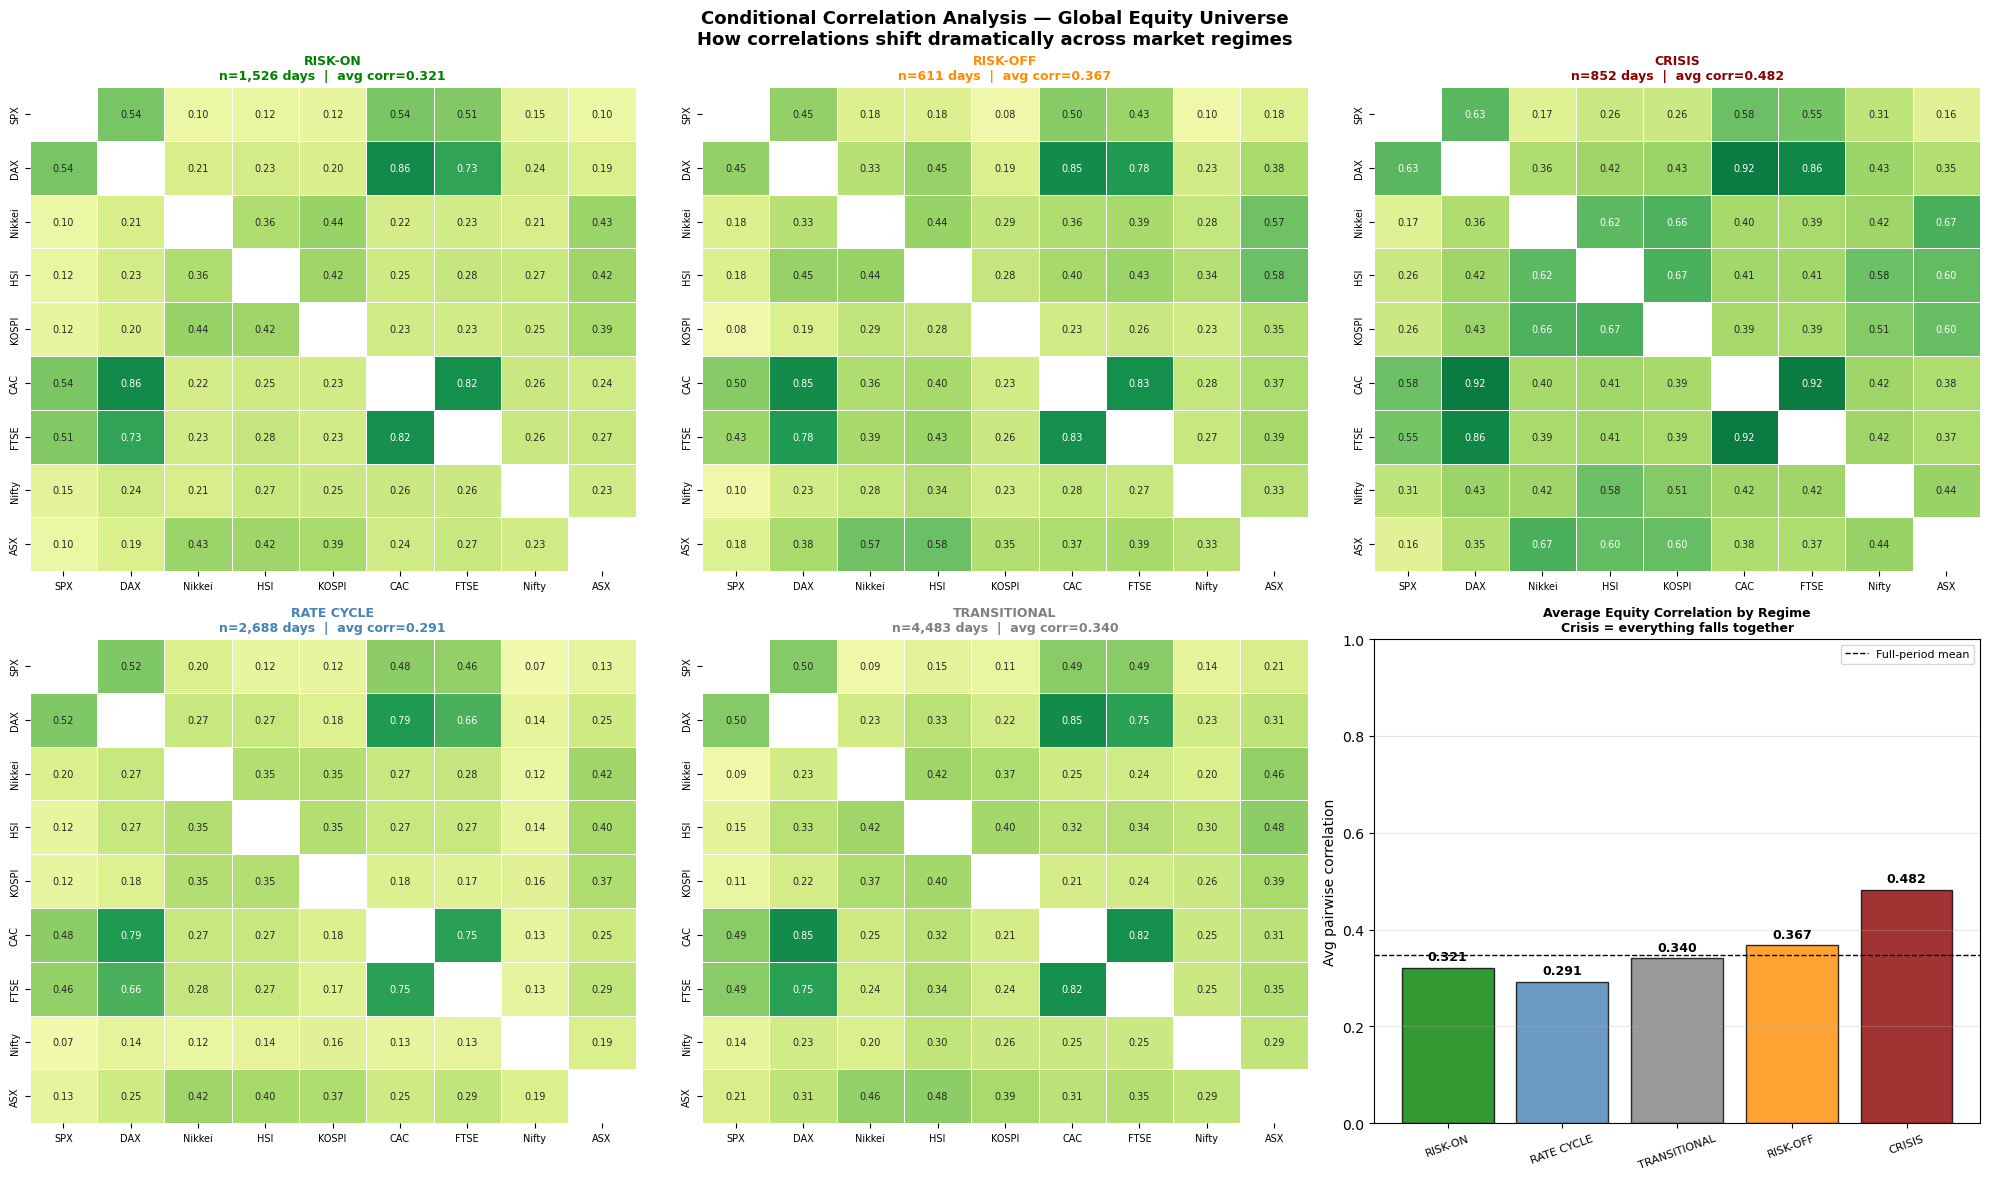


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\09_conditional_correlations.png


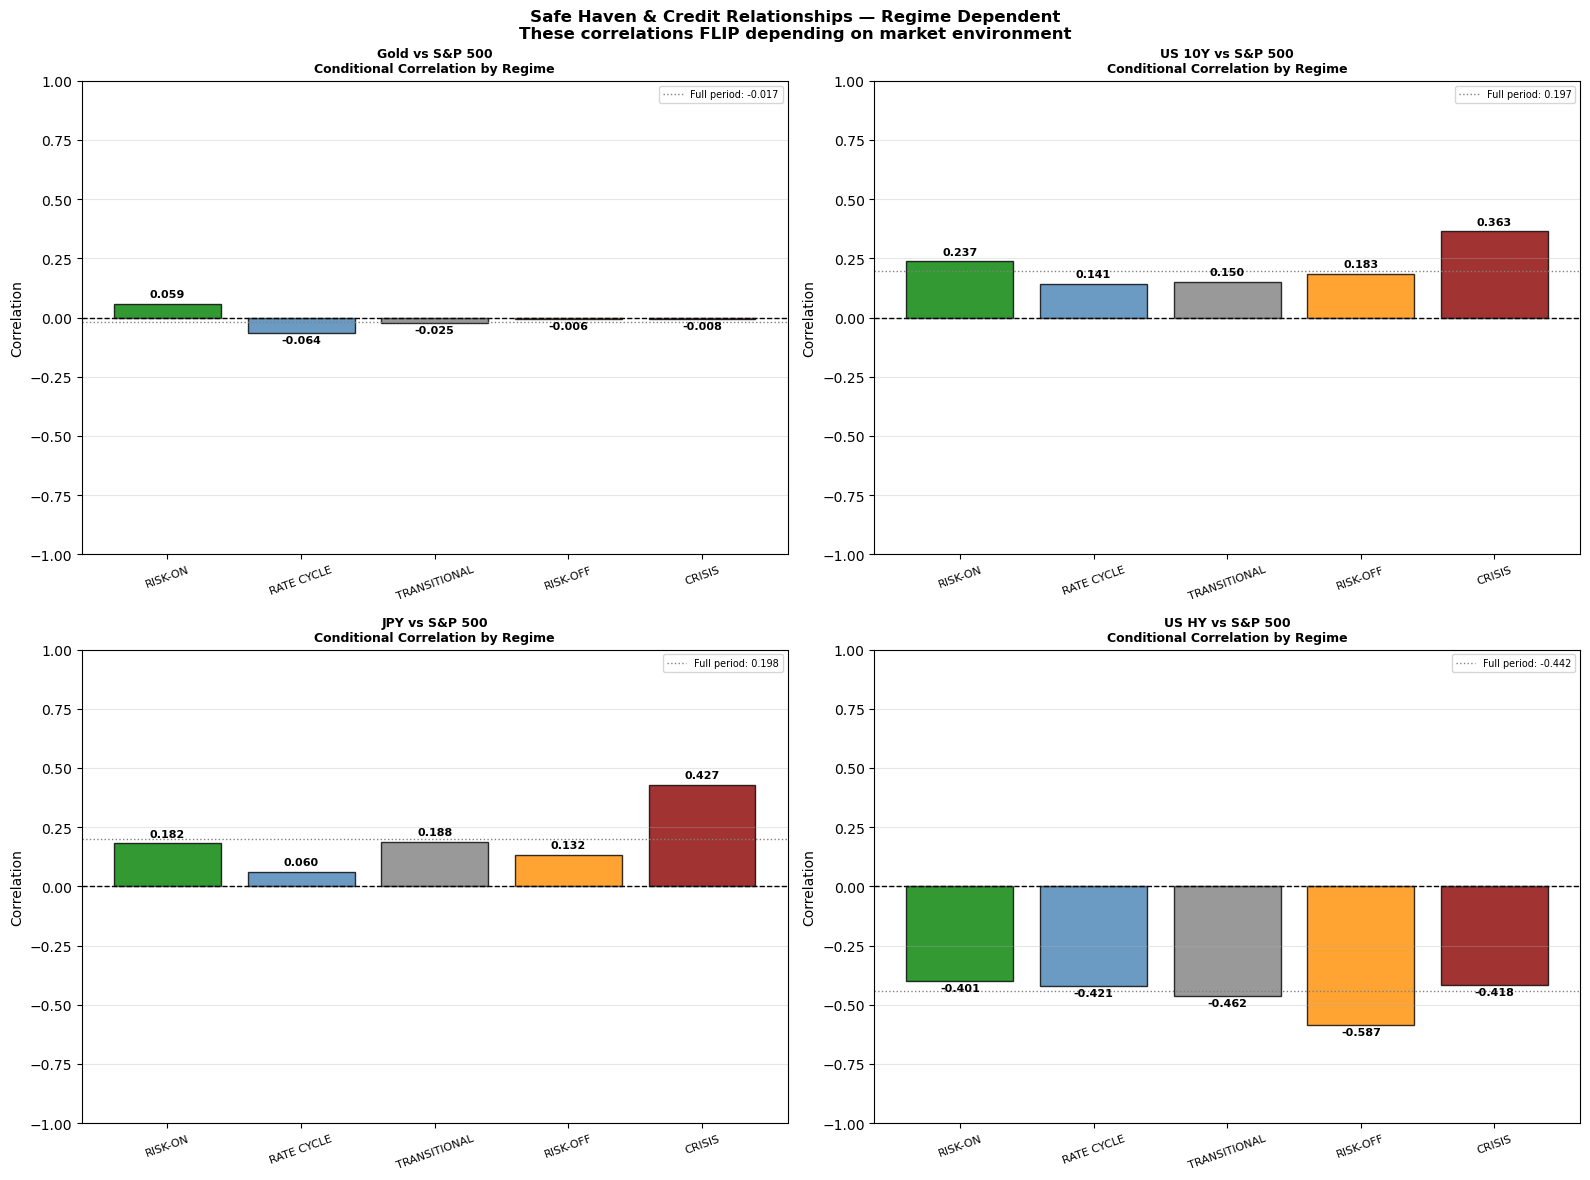

Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\09_safe_haven_conditional.png
Conditional correlations saved.


In [9]:
# ── Cell 3: Conditional Correlation Analysis ──────────────────────────────────
#
# The core insight: correlations are not stable across market regimes.
# A correlation computed across all 36 years hides the most important truth:
# the relationship between two assets in a CRISIS is completely different
# from their relationship in a GOLDILOCKS period.
#
# This is where the real edge lives.

import matplotlib.dates as mdates

# ── Load regime history ───────────────────────────────────────────────────────
regime_hist = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "global_regime_history.csv"),
    index_col="date", parse_dates=True
)

# ── Define regime groups ──────────────────────────────────────────────────────
# We group the 11 regimes into 4 macro buckets for cleaner analysis
def map_to_macro_regime(regime):
    risk_on  = ["GOLDILOCKS", "RISK-ON", "RECOVERY"]
    risk_off = ["RISK-OFF", "GROWTH SCARE", "STAGFLATION"]
    crisis   = ["FINANCIAL CRISIS", "RECESSION"]
    tight    = ["TIGHTENING CYCLE", "EASING CYCLE"]
    if regime in risk_on:  return "RISK-ON"
    if regime in risk_off: return "RISK-OFF"
    if regime in crisis:   return "CRISIS"
    if regime in tight:    return "RATE CYCLE"
    return "TRANSITIONAL"

regime_hist["macro_regime"] = regime_hist["regime"].apply(map_to_macro_regime)

# ── Align regime with returns ─────────────────────────────────────────────────
common_dates = returns.index.intersection(regime_hist.index)
ret_aligned  = returns.loc[common_dates]
reg_aligned  = regime_hist.loc[common_dates, "macro_regime"]

print("Macro regime distribution:")
print(reg_aligned.value_counts().to_string())
print()

# ── 3A: Conditional correlations for key pairs ────────────────────────────────
MACRO_REGIMES = ["RISK-ON", "RISK-OFF", "CRISIS", "RATE CYCLE", "TRANSITIONAL"]

REGIME_COLORS = {
    "RISK-ON":      "green",
    "RISK-OFF":     "darkorange",
    "CRISIS":       "darkred",
    "RATE CYCLE":   "steelblue",
    "TRANSITIONAL": "grey",
}

print("Conditional Correlations by Macro Regime:")
print("="*85)
print(f"  {'Pair':<22}  {'ALL':>6}  {'RISK-ON':>8}  "
      f"{'RISK-OFF':>9}  {'CRISIS':>8}  {'RATE CYCLE':>11}")
print("-"*85)

conditional_results = {}

for pair_name, (t1, t2) in PAIRS.items():
    if t1 not in ret_aligned.columns or t2 not in ret_aligned.columns:
        continue

    s1 = ret_aligned[t1]
    s2 = ret_aligned[t2]

    row = {"ALL": s1.corr(s2)}
    for regime in MACRO_REGIMES:
        mask   = reg_aligned == regime
        n_obs  = mask.sum()
        if n_obs >= 63:
            row[regime] = s1[mask].corr(s2[mask])
        else:
            row[regime] = np.nan

    conditional_results[pair_name] = row

    all_c    = row.get("ALL",        np.nan)
    ron_c    = row.get("RISK-ON",    np.nan)
    roff_c   = row.get("RISK-OFF",   np.nan)
    crisis_c = row.get("CRISIS",     np.nan)
    rate_c   = row.get("RATE CYCLE", np.nan)

    # Flag if correlation changes significantly across regimes
    vals   = [v for v in [ron_c, roff_c, crisis_c] if pd.notna(v)]
    spread = max(vals) - min(vals) if len(vals) > 1 else 0
    flag   = " ← REGIME DEPENDENT" if spread > 0.3 else ""

    print(f"  {pair_name:<22}  {all_c:>+6.3f}  "
          f"{ron_c:>+8.3f}  {roff_c:>+9.3f}  "
          f"{crisis_c:>+8.3f}  {rate_c:>+11.3f}{flag}")

print()


# ── 3B: Full matrix conditional correlations for equity universe ──────────────
print("Equity matrix correlations by regime:")
print("-"*50)

eq_tickers = [
    "SPX Index","DAX Index","NKY Index","HSI Index",
    "KOSPI Index","CAC Index","UKX Index","NIFTY Index","AS51 Index"
]
eq_tickers  = [t for t in eq_tickers if t in ret_aligned.columns]
eq_labels_c = ["SPX","DAX","Nikkei","HSI","KOSPI","CAC","FTSE","Nifty","ASX"]

corr_by_regime = {}
for regime in MACRO_REGIMES:
    mask = reg_aligned == regime
    if mask.sum() >= 63:
        corr_by_regime[regime] = ret_aligned.loc[mask, eq_tickers].corr()
        avg = corr_by_regime[regime].values[np.triu_indices(
            len(eq_tickers), k=1)].mean()
        print(f"  {regime:<15}  n={mask.sum():>5} days  "
              f"avg pairwise corr={avg:.3f}")


# ── 3C: Visualise conditional correlations ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, regime in enumerate(["RISK-ON","RISK-OFF","CRISIS",
                                "RATE CYCLE","TRANSITIONAL"]):
    if regime not in corr_by_regime:
        axes[idx].set_visible(False)
        continue

    ax  = axes[idx]
    cm  = corr_by_regime[regime]
    cm.index   = eq_labels_c
    cm.columns = eq_labels_c

    n_reg = (reg_aligned == regime).sum()
    avg_c = cm.values[np.triu_indices(len(eq_labels_c), k=1)].mean()

    sns.heatmap(
        cm,
        ax        = ax,
        cmap      = "RdYlGn",
        center    = 0,
        vmin      = -0.2, vmax = 1.0,
        annot     = True,
        fmt       = ".2f",
        annot_kws = {"size": 7},
        linewidths= 0.5,
        linecolor = "white",
        cbar      = False,
        mask      = np.eye(len(eq_labels_c), dtype=bool)
    )
    color = REGIME_COLORS.get(regime, "grey")
    ax.set_title(f"{regime}\n"
                 f"n={n_reg:,} days  |  avg corr={avg_c:.3f}",
                 fontsize=9, fontweight="bold", color=color)
    ax.tick_params(labelsize=7)

# Last panel: bar chart of avg correlation by regime
ax = axes[5]
regimes_ordered = ["RISK-ON","RATE CYCLE","TRANSITIONAL","RISK-OFF","CRISIS"]
avg_corrs = []
colors_bar = []
for r in regimes_ordered:
    if r in corr_by_regime:
        cm  = corr_by_regime[r]
        avg = cm.values[np.triu_indices(len(eq_labels_c), k=1)].mean()
        avg_corrs.append(avg)
        colors_bar.append(REGIME_COLORS.get(r, "grey"))
    else:
        avg_corrs.append(0)
        colors_bar.append("grey")

bars = ax.bar(regimes_ordered, avg_corrs, color=colors_bar, alpha=0.8, edgecolor="black")
ax.axhline(avg_eq_corr_252.dropna().mean(), color="black",
           lw=1.0, ls="--", label="Full-period mean")
for bar, val in zip(bars, avg_corrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_title("Average Equity Correlation by Regime\n"
             "Crisis = everything falls together",
             fontsize=9, fontweight="bold")
ax.set_ylabel("Avg pairwise correlation")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

fig.suptitle("Conditional Correlation Analysis — Global Equity Universe\n"
             "How correlations shift dramatically across market regimes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "09_conditional_correlations.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")


# ── 3D: The most important chart — regime-dependent safe haven relationships ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

safe_pairs_cond = {
    "Gold vs S&P 500":    ("GC1 Comdty",     "SPX Index"),
    "US 10Y vs S&P 500":  ("USGG10YR Index", "SPX Index"),
    "JPY vs S&P 500":     ("USDJPY Curncy",  "SPX Index"),
    "US HY vs S&P 500":   ("LF98OAS Index",  "SPX Index"),
}

for idx, (pair_name, (t1, t2)) in enumerate(safe_pairs_cond.items()):
    ax = axes[idx // 2][idx % 2]

    if t1 not in ret_aligned.columns or t2 not in ret_aligned.columns:
        continue

    s1 = ret_aligned[t1]
    s2 = ret_aligned[t2]

    # Correlation by regime
    regime_corrs = {}
    for regime in MACRO_REGIMES:
        mask = reg_aligned == regime
        if mask.sum() >= 63:
            regime_corrs[regime] = s1[mask].corr(s2[mask])

    regimes_plot = [r for r in regimes_ordered if r in regime_corrs]
    corrs_plot   = [regime_corrs[r] for r in regimes_plot]
    colors_plot  = [REGIME_COLORS.get(r, "grey") for r in regimes_plot]

    bars = ax.bar(regimes_plot, corrs_plot,
                  color=colors_plot, alpha=0.8, edgecolor="black")
    ax.axhline(0, color="black", lw=1.0, ls="--")
    ax.axhline(s1.corr(s2), color="grey", lw=1.0, ls=":",
               label=f"Full period: {s1.corr(s2):.3f}")

    for bar, val in zip(bars, corrs_plot):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (0.02 if val >= 0 else -0.05),
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

    ax.set_title(f"{pair_name}\nConditional Correlation by Regime",
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("Correlation")
    ax.set_ylim(-1.0, 1.0)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Safe Haven & Credit Relationships — Regime Dependent\n"
             "These correlations FLIP depending on market environment",
             fontsize=12, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "09_safe_haven_conditional.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

# ── Save conditional correlations ─────────────────────────────────────────────
cond_out = pd.DataFrame(conditional_results).T
cond_out.to_csv(os.path.join(
    cfg.OUT_PATH, "correlation_matrices", "conditional_correlations.csv"
))
print("Conditional correlations saved.")

Composite Correlation Instability:
  Current Z-score : -0.25
  Percentile      : 35.4th
  Regime          : NORMAL

Per-pair instability (current):
-------------------------------------------------------
  Europe→US           corr=+0.434  instability Z=-1.00  ✓
  Gold vs SPX         corr=+0.089  instability Z=-0.94  ✓
  10Y vs SPX          corr=+0.162  instability Z=+1.66  ⚠ UNSTABLE
  HY vs SPX           corr=-0.653  instability Z=+0.64  ✓
  AUDJPY vs SPX       corr=+0.639  instability Z=-0.55  ✓
  JPY vs SPX          corr=+0.161  instability Z=-1.30  ✓

Predictive power of instability for crisis (% of days followed by crisis):
  Inst Z >    30D ahead  60D ahead  90D ahead
---------------------------------------------
  0.0              5.2%       6.0%       7.1%  (n=4,979)
  0.5              4.9%       2.7%       2.4%  (n=2,134)
  1.0              5.6%       2.4%       0.3%  (n=675)
  1.5              0.0%       0.0%       0.0%  (n=227)
  2.0              0.0%       0.0%       0.0%  

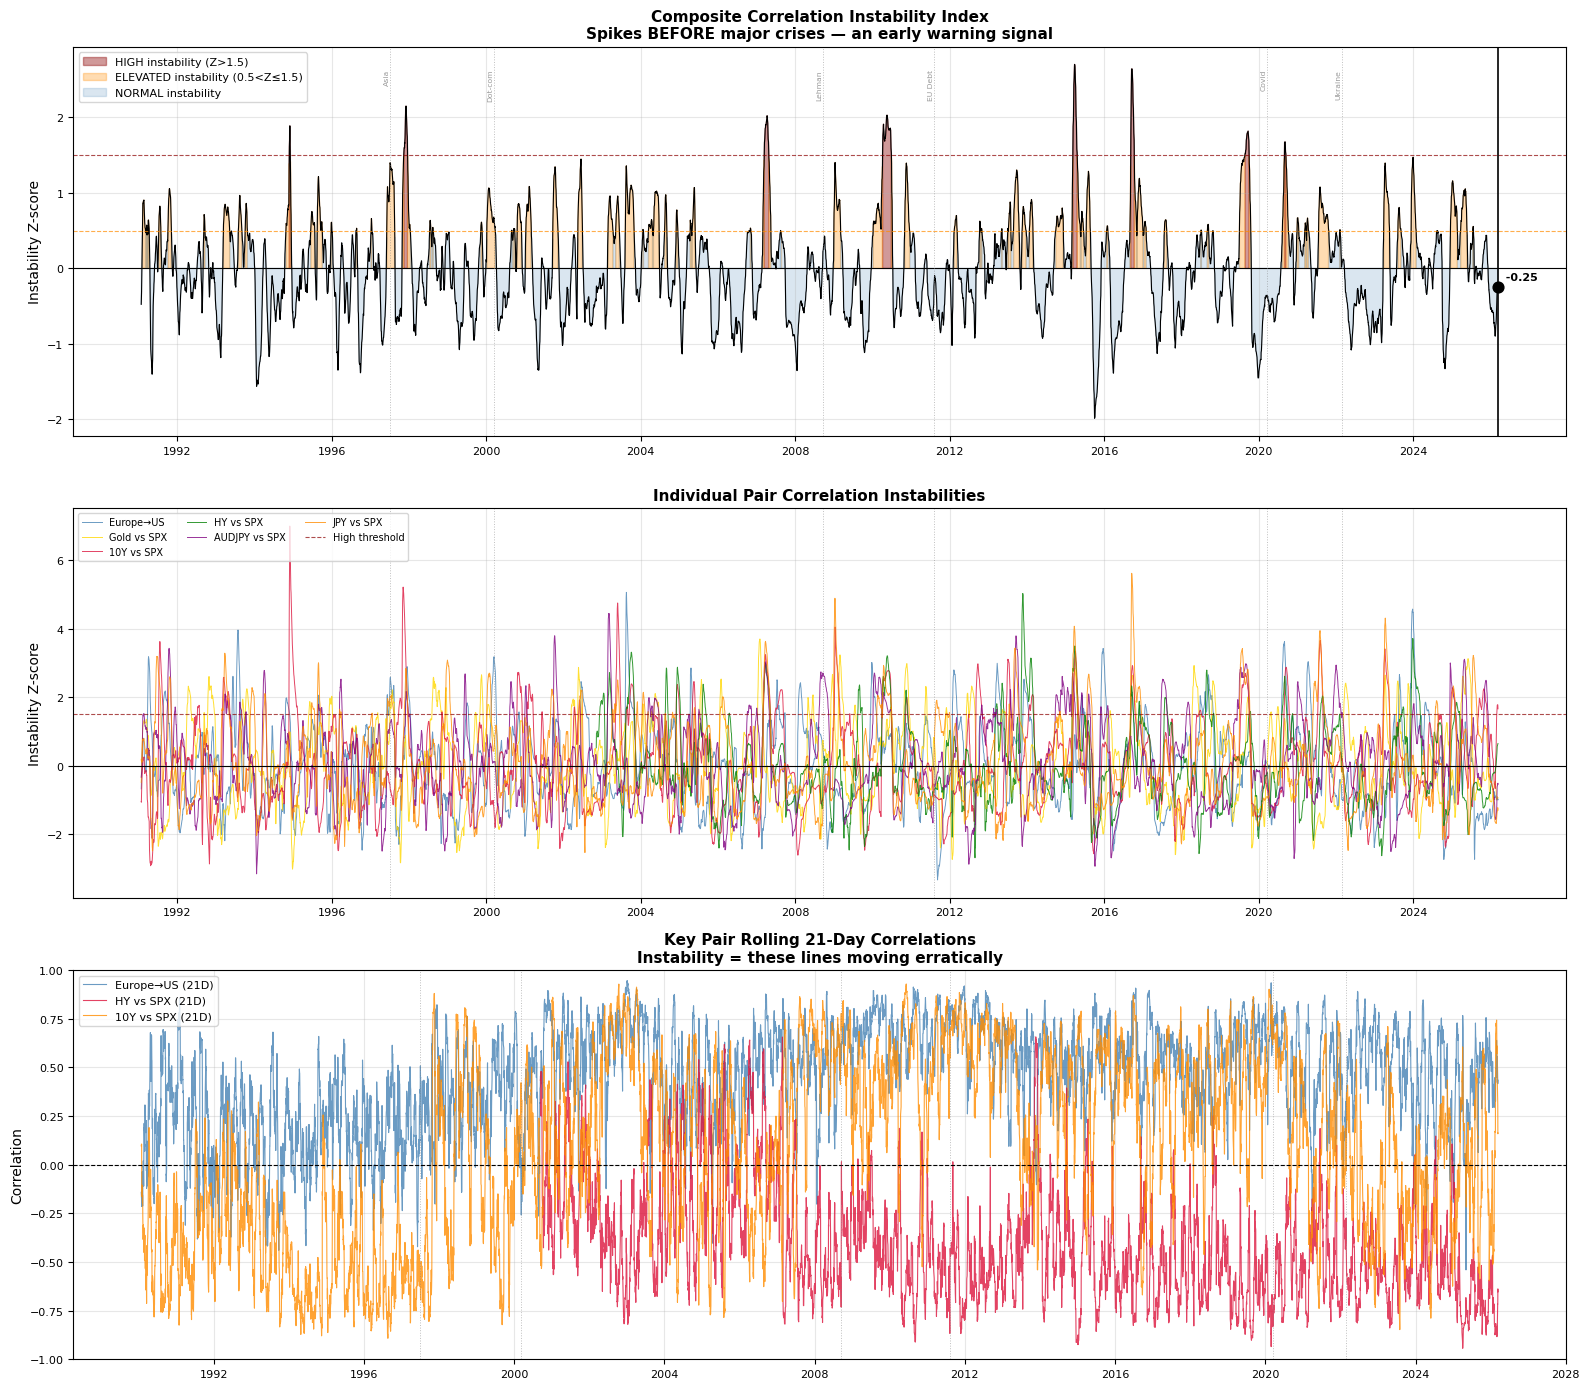


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\09_correlation_instability.png
Instability index saved.


In [10]:
# ── Cell 4: Correlation Instability as Crisis Early Warning ──────────────────
#
# When the correlation structure starts CHANGING rapidly,
# it means a regime shift is underway — even before prices move dramatically.
# This is one of the earliest and most reliable leading indicators.

import matplotlib.dates as mdates

# ── 4A: Correlation instability index ────────────────────────────────────────
# For each key pair, compute:
#   1. Rolling 21-day correlation
#   2. Rolling 63-day std of that 21-day correlation = instability
#   3. Z-score of instability vs its own history

INSTABILITY_PAIRS = {
    "Europe→US":    ("DAX Index",      "SPX Index"),
    "Gold vs SPX":  ("GC1 Comdty",     "SPX Index"),
    "10Y vs SPX":   ("USGG10YR Index", "SPX Index"),
    "HY vs SPX":    ("LF98OAS Index",  "SPX Index"),
    "AUDJPY vs SPX":("AUDJPY Curncy",  "SPX Index"),
    "JPY vs SPX":   ("USDJPY Curncy",  "SPX Index"),
}

instability_scores = {}

for pair_name, (t1, t2) in INSTABILITY_PAIRS.items():
    if t1 not in returns.columns or t2 not in returns.columns:
        continue
    s1 = returns[t1]
    s2 = returns[t2]
    roll_21   = s1.rolling(21).corr(s2)
    inst      = roll_21.rolling(63).std()
    inst_z    = (inst - inst.rolling(252).mean()) / inst.rolling(252).std()
    instability_scores[pair_name] = {
        "roll_21": roll_21,
        "inst":    inst,
        "inst_z":  inst_z,
    }

# Composite instability index — average z-score across all pairs
inst_z_all = pd.concat(
    [v["inst_z"] for v in instability_scores.values()], axis=1
)
composite_instability = inst_z_all.mean(axis=1)
composite_instability.name = "Composite Correlation Instability"

cur_inst = composite_instability.dropna().iloc[-1]
inst_pctile = (composite_instability.dropna() < cur_inst).sum() / \
               len(composite_instability.dropna()) * 100

print("Composite Correlation Instability:")
print(f"  Current Z-score : {cur_inst:>+.2f}")
print(f"  Percentile      : {inst_pctile:.1f}th")
regime_inst = ("HIGH — regime change underway" if cur_inst > 1.5 else
               "ELEVATED — monitor closely"    if cur_inst > 0.5 else
               "NORMAL")
print(f"  Regime          : {regime_inst}")
print()

# Per-pair current instability
print("Per-pair instability (current):")
print("-"*55)
for pair_name, data in instability_scores.items():
    cur_z   = data["inst_z"].dropna().iloc[-1]
    cur_r   = data["roll_21"].dropna().iloc[-1]
    flag    = "⚠ UNSTABLE" if cur_z > 1.5 else "✓"
    print(f"  {pair_name:<18}  corr={cur_r:>+.3f}  "
          f"instability Z={cur_z:>+.2f}  {flag}")


# ── 4B: Does instability LEAD crises? ────────────────────────────────────────
# Test: does high composite instability predict future crisis regimes?

# Load regime history
regime_hist = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "global_regime_history.csv"),
    index_col="date", parse_dates=True
)
regime_hist["macro_regime"] = regime_hist["regime"].apply(map_to_macro_regime)
is_crisis = (regime_hist["macro_regime"] == "CRISIS").astype(int)
is_crisis = is_crisis.reindex(composite_instability.index).ffill()

# For each level of instability, what fraction of days are followed
# by crisis within 30, 60, 90 days?
inst_aligned  = composite_instability.dropna()
crisis_aligned = is_crisis.reindex(inst_aligned.index).ffill()

thresholds = [0.0, 0.5, 1.0, 1.5, 2.0]
horizons   = [30, 60, 90]

print("\nPredictive power of instability for crisis (% of days followed by crisis):")
print(f"  {'Inst Z >':<10}", end="")
for h in horizons:
    print(f"  {h}D ahead", end="")
print()
print("-"*45)

for thresh in thresholds:
    high_inst = inst_aligned[inst_aligned > thresh]
    print(f"  {thresh:<10.1f}", end="")
    for horizon in horizons:
        crisis_fwd = crisis_aligned.shift(-horizon).reindex(high_inst.index)
        pct = crisis_fwd.mean() * 100
        print(f"  {pct:>8.1f}%", end="")
    print(f"  (n={len(high_inst):,})")


# ── 4C: Plots ─────────────────────────────────────────────────────────────────
CRISES = [
    ("1997-07-02","Asia"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2011-08-05","EU Debt"),
    ("2020-03-16","Covid"),("2022-02-24","Ukraine"),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ── Panel 1: Composite instability with crisis overlay ────────────────────────
ax1 = axes[0]
ci  = composite_instability.dropna()
ax1.fill_between(ci.index, ci.values, 0,
                 where=ci.values > 1.5,
                 alpha=0.4, color="darkred",
                 label="HIGH instability (Z>1.5)")
ax1.fill_between(ci.index, ci.values, 0,
                 where=(ci.values > 0.5) & (ci.values <= 1.5),
                 alpha=0.3, color="darkorange",
                 label="ELEVATED instability (0.5<Z≤1.5)")
ax1.fill_between(ci.index, ci.values, 0,
                 where=ci.values <= 0.5,
                 alpha=0.2, color="steelblue",
                 label="NORMAL instability")
ax1.plot(ci.index, ci.values, lw=0.8, color="black")
ax1.axhline(1.5, color="darkred",   lw=0.8, ls="--", alpha=0.7)
ax1.axhline(0.5, color="darkorange",lw=0.8, ls="--", alpha=0.7)
ax1.axhline(0,   color="black",     lw=0.8)

# Mark current
ax1.axvline(ci.index[-1], color="black", lw=1.2)
ax1.scatter([ci.index[-1]], [cur_inst], s=60, color="black", zorder=5)
ax1.text(ci.index[-1], cur_inst + 0.1,
         f"  {cur_inst:+.2f}", fontsize=8, fontweight="bold")

for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
    ax1.text(pd.Timestamp(crisis_date), ax1.get_ylim()[1]*0.9,
             label, fontsize=5.5, rotation=90, va="top",
             ha="right", color="grey", alpha=0.8)

ax1.set_title("Composite Correlation Instability Index\n"
              "Spikes BEFORE major crises — an early warning signal",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Instability Z-score")
ax1.legend(fontsize=8, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# ── Panel 2: Individual pair instabilities ────────────────────────────────────
ax2 = axes[1]
colors_inst = ["steelblue","gold","crimson","green","purple","darkorange"]
for (pair_name, data), color in zip(instability_scores.items(), colors_inst):
    iz = data["inst_z"].dropna()
    ax2.plot(iz.index, iz.values, lw=0.7, color=color,
             alpha=0.8, label=pair_name)
ax2.axhline(1.5, color="darkred", lw=0.8, ls="--", alpha=0.7,
            label="High threshold")
ax2.axhline(0,   color="black",   lw=0.8)
for crisis_date, _ in CRISES:
    ax2.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax2.set_title("Individual Pair Correlation Instabilities",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Instability Z-score")
ax2.legend(fontsize=7, loc="upper left", ncol=3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# ── Panel 3: 21-day rolling correlation for three key pairs ──────────────────
ax3 = axes[2]
key_pairs = ["Europe→US", "HY vs SPX", "10Y vs SPX"]
key_colors = ["steelblue", "crimson", "darkorange"]
for pair, color in zip(key_pairs, key_colors):
    if pair in instability_scores:
        r21 = instability_scores[pair]["roll_21"].dropna()
        ax3.plot(r21.index, r21.values, lw=0.8,
                 color=color, alpha=0.8, label=f"{pair} (21D)")
ax3.axhline(0, color="black", lw=0.8, ls="--")
for crisis_date, label in CRISES:
    ax3.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax3.set_title("Key Pair Rolling 21-Day Correlations\n"
              "Instability = these lines moving erratically",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Correlation")
ax3.set_ylim(-1.0, 1.0)
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "09_correlation_instability.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save instability index ────────────────────────────────────────────────────
inst_out = pd.DataFrame({
    "composite_instability": composite_instability,
    **{f"{k}_inst_z": v["inst_z"] for k, v in instability_scores.items()},
    **{f"{k}_roll21": v["roll_21"] for k, v in instability_scores.items()},
})
inst_out.to_csv(os.path.join(
    cfg.OUT_PATH, "correlation_matrices", "instability_index.csv"
))
print("Instability index saved.")